## Теория (0.25 балла за ответ)

1. Какая глубина в среднем будет у дерева решений, построенного на 10_000_000 объектах?

In [1]:
import math
n=10000000
math.log2(n)
#считаем так потому что при разбиении узел делит выборку пополам

23.253496664211536

2. Во сколько раз изменится скорость обучения дерева решений, если увеличить число признаков в 10 раз?

In [2]:
#в 10 раз станет медленнее
#так как для поиска лучшего разиения мы перебирем все признаки и их пороги, а при увеличении числа признаков линейно падает в 10 раз скорость обучения

3. Можете ли быть `gini impurity` ребенка выше, чем у родителя?

In [3]:
#если разбиение неэффективно, то может быть
#например родитель (AA AABBCC) gini 0.625=1-(0.5**2+0.25**2+0.25**2=0.375) -> 1. ребенок 1 (АА) gini(0) 1-1**2=0 -> ребёнок 2 (AABBCC) gini= 1-(0.33**2)+(0.33)**2+(0.33)**2 = 0,667

4* Может ли быть такое разбиение в дереве решений, что `gini impurity decrease` для данного разбиения меньше 0? Докажите

In [4]:
#на листочке, показала на семинаре

5. Предположим, что мы разрешаем дереву решений бесконечно расти в глубину. Может ли в результате этого получится дерево, в котором есть лист с не меньше чем двумя объектами, принадлежащими к разным классам?

In [5]:
#Да, когда есть противоричивые объекты, которые имеют одинаковые значения признаков, но с разным классами:
    'признак_1': [1, 1],
    'признак_2': [2, 2],
    'признак_3': [3, 3],
    'класс': ['A', 'B'] #невозможно разделить

IndentationError: unexpected indent (2566468124.py, line 2)

## Задача 2: ДАЛС (1 балл)

1. Сгенерируйте датасет лун используя команду `make_moons(n_samples=10000, noise=0.4)`. Разбейте его на обучение и тест, обучить дерево решений (подумайте, как правильно подобрать параметры дерева). Оцените качество на итоговом датасете

In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons

In [89]:
X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
#Разбиение на обучающий (80%) и тестовый (20%) наборы
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [92]:
import numpy as np

In [93]:
training = X_train.shape[0]
testing = X_test.shape[0]
dim_train = np.bincount(y_train)
dim_test = np.bincount(y_test)
training,testing,dim_train,dim_test

(8000, 2000, array([4000, 4000]), array([1000, 1000]))

In [94]:
#Основные параметры для настройки: глубина дерева, минимальное количество объектов для разбиения узла, мин.кол. объектов в листе, макс. количество листьев

param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [10, 20, 50, 100, None]
}

In [95]:
#дерево решений
dt = DecisionTreeClassifier(random_state=42)

In [96]:
from sklearn.model_selection import GridSearchCV

In [97]:
#подбираю парамтеры для кросс валидации
grid_search = GridSearchCV(
    dt, param_grid, cv=5,
    scoring='accuracy',
    verbose=1
)

In [98]:
#подбор гиперпарамеров
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 400 candidates, totalling 2000 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, 20, None],
                         'max_leaf_nodes': [10, 20, 50, 100, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=1)

In [99]:
best_param = grid_search.best_params_
best_cros_val = grid_search.best_score_
best_param, best_cros_val

({'max_depth': 10,
  'max_leaf_nodes': 20,
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 np.float64(0.858125))

In [100]:
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)
best_tree, y_pred

(DecisionTreeClassifier(max_depth=10, max_leaf_nodes=20, random_state=42),
 array([0, 1, 0, ..., 1, 1, 1]))

In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [102]:
#Метрики качества
accuracy = accuracy_score(y_test, y_pred)
accyracy_on_test = accuracy
print(accuracy)
print(classification_report(y_test, y_pred, target_names=['Класс 0', 'Класс 1']))


0.853
              precision    recall  f1-score   support

     Класс 0       0.87      0.83      0.85      1000
     Класс 1       0.84      0.88      0.86      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [103]:
cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

Матрица ошибок:
[[830 170]
 [124 876]]


*2*. Повлияет ли на качество дерева предварительное масштабирование признаков?

In [ ]:
#Нет, не влияет на качество дерева решений, так как деревья решений принимаюи решения на основе пороговых сравнений значений признаков

3. Постройте границы решений для трех деревьев решений, обученных на датасетах, полученных выполнением функции make_moons с разными сидами

In [104]:
#функция для отрисовки границ решения
def plot_decision_boundary(model, X, y, ax, title, alpha=0.3):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=alpha, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=15, cmap=plt.cm.RdYlBu,
               edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")

# Параметры
n_samples = 1000
noise = 0.3
test_size = 0.2
max_depth = 10

# Разные random_state для генерации данных
random_states = [42, 123, 777]
trees = []
datasets = []


In [105]:
import matplotlib.pyplot as plt

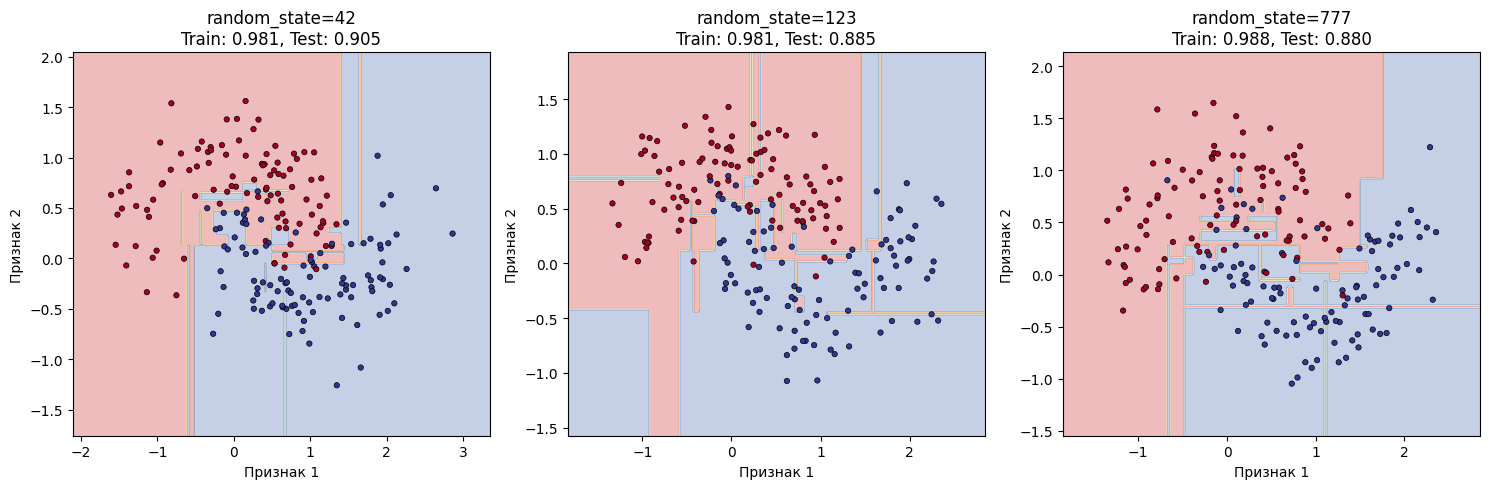

In [106]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, rs in enumerate(random_states):
    # Генерация данных с разным сидом
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=rs)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42  # фиксируем разбиение
    )

    # Обучение дерева
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_train, y_train)

    # Оценка качества
    train_acc = dt.score(X_train, y_train)
    test_acc = dt.score(X_test, y_test)

    # Визуализация на тестовых данных
    plot_decision_boundary(dt, X_test, y_test, axes[idx],
                          f"random_state={rs}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}")

    trees.append(dt)
    datasets.append((X, y))

plt.tight_layout()
plt.show()

In [107]:
for i in range(len(trees)):
    for j in range(i+1, len(trees)):
        _, X_test, _, _ = train_test_split(datasets[0][0], datasets[0][1],
                                           test_size=test_size, random_state=42)
        pred_i = trees[i].predict(X_test)
        pred_j = trees[j].predict(X_test)
        agreement = np.mean(pred_i == pred_j)
        print(f"Согласованность дерева {random_states[i]} и {random_states[j]}: {agreement:.4f}")

Согласованность дерева 42 и 123: 0.8850
Согласованность дерева 42 и 777: 0.8600
Согласованность дерева 123 и 777: 0.8950


4. Можно ли добиться того, что деревья, построенные с разными сидами, будут одинаковыми?

In [109]:
'''Чтобы получить одинаковые деревья, нужно обеспечить одинаковые обучающие данные и алгоритм, который даёт один и тот же результат, при одинаквкых данных.
 Разные random_state в make_moons гарантированно дают разные данные, а значит — разные деревья(это можно попробовать обойти только если у нас будут маленькие выборки
 или отсуствующий шум). То есть, разные данные влекут за собой разные деревья, и наоборот, разные сиды дают разные наборы точек и тоже разгые деревья.
 Таким образом, ответ - нет.
'''

'Чтобы получить одинаковые деревья, нужно обеспечить одинаковые обучающие данные и алгоритм, который даёт один и тот же результат, при одинаквкых данных.\n Разные random_state в make_moons гарантированно дают разные данные, а значит — разные деревья(это можно попробовать обойти только если у нас будут маленькие выборки\n или отсуствующий шум). То есть, разные данные влекут за собой разные деревья, и наоборот, разные сиды дают разные наборы точек и тоже разгые деревья.\n Таким образом, ответ - нет.\n'

## Задача 3: Древесные модели и работа с признаками (1 балл)



Поработаем с  [датасетом](https://www.kaggle.com/ronitf/heart-disease-uci), содержащим признаковые описания здоровых людей и пациентов с заболеваниями сердца.

In [110]:
!wget https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/heart_uci_cleveland.csv -O heart.csv

--2026-04-22 19:23:28--  https://data.bioml.ru/htdocs/courses/python/datasci/pandas/data/heart_uci_cleveland.csv
Resolving data.bioml.ru (data.bioml.ru)... 188.120.231.217
Connecting to data.bioml.ru (data.bioml.ru)|188.120.231.217|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11106 (11K) [text/csv]
Saving to: ‘heart.csv’

heart.csv           100%[===================>]  10.85K  --.-KB/s    in 0s      

2026-04-22 19:23:29 (172 MB/s) - ‘heart.csv’ saved [11106/11106]



In [111]:
import pandas as pd

In [115]:
import numpy as np
from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [113]:
heart_dataset = pd.read_csv("heart.csv")
print(heart_dataset.shape)
print(heart_dataset.columns.values)
X = heart_dataset.drop("condition", axis=1)
y = heart_dataset["condition"] > 0
X_train, X_test, y_train, y_test = train_test_split(X, y.values, random_state=777)

(297, 14)
['age' 'sex' 'cp' 'trestbps' 'chol' 'fbs' 'restecg' 'thalach' 'exang'
 'oldpeak' 'slope' 'ca' 'thal' 'condition']


In [114]:
heart_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


### Эксперимент: обучение классификаторов на вещественных признаках

Качество алгоритмов может зависеть не только от значений гиперпараметров, но и от предобратки исходных признаков. Некоторые из рассмотренных нами алгоритмов чувствительны к масштабу признаков. Посмотрим, насколько различны распределения признаков. Постройте гистограммы для признаков age, trestbps, chol, thalach, oldpeak.

Глядя на получившиеся графики, скажите в чем заключается особенность данных? На какие алгоритмы это может повлиять? Почему?

In [13]:
import matplotlib.pyplot as plt


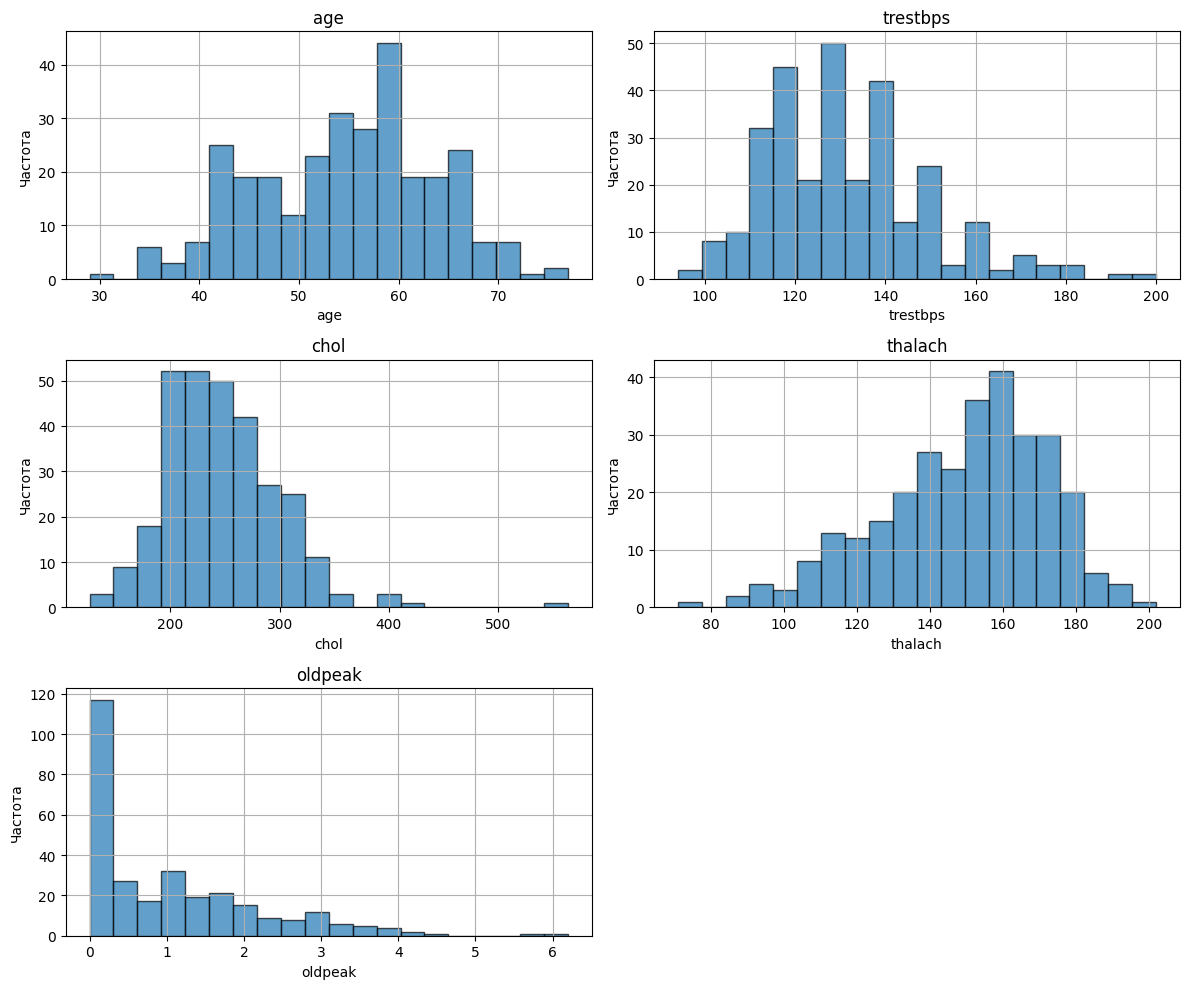

In [14]:
plt.figure(figsize=(12, 10))
features_to_plot = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

for i, name in enumerate(features_to_plot, 1):
    plt.subplot(3, 2, i)  # Убрал +1, так как i начинается с 1
    heart_dataset[name].hist(bins=20, edgecolor='black', alpha=0.7)
    plt.title(name, fontsize=12)
    plt.xlabel(name)
    plt.ylabel('Частота')
plt.tight_layout()
plt.show()

**Глядя на гистограммы, можно заметить:**

Разные масштабы признаков по оси Y
Разные распределения - некоторые признаки близки к нормальному (age, trestbps), а oldpeak,thalach,chol имеют скошенное распределение
Выбросы - особенно заметны в chol
Это влияет на чувствительные к масштабу алгоритмы , такие как - логистическая регрессия, SVM, нейронные сети, методы на основе расстояний, а нечувствительными, в свою очередь будут - деревья решений, метод k-ближайших соседей (kNN)

Масштабирование признаков можно выполнить, например, одним из следующих способов:

$x_{new} = \dfrac{x - \mu}{\sigma}$, где $\mu, \sigma$ — среднее и стандартное отклонение значения признака по всей выборке;

$x_{new} = \dfrac{x - x_{min}}{x_{max} - x_{min}}$, где $[x_{min}, x_{max}]$ —  интервал наблюдаемых значений признака.

Такие схемы масштабирования приведены в классах [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) и [MinMaxScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler).

Отберите все вещественные признаки и масштабируйте их одним из указанных способов.




In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


В этой задаче будем рассматривать алгоритм DecisionTreeClassifier

При помощи отложенной валидационной выборке сравните качество работы алгоритма
 параметрами по умолчанию на масштабированных и исходных вещественных признаках

Сделайте вывод о необходимости масштабировать признаки перед подачей их в древесные модели.

In [16]:
#отбираем вещественные признаки
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

#StandardScaler(первая формула)
scaler_standard = StandardScaler()
X_train_standard = X_train.copy()
X_test_standard = X_test.copy()
X_train_standard[numeric_features] = scaler_standard.fit_transform(X_train[numeric_features])
X_test_standard[numeric_features] = scaler_standard.transform(X_test[numeric_features])

In [17]:
#MinMaxScaler(вторая формула)
scaler_minmax = MinMaxScaler()
X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()
X_train_minmax[numeric_features] = scaler_minmax.fit_transform(X_train[numeric_features])
X_test_minmax[numeric_features] = scaler_minmax.transform(X_test[numeric_features])

Сделайте выводы.

In [18]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier



In [32]:
#Обучение на исходных данных
dt_original = DecisionTreeClassifier(random_state=42)
dt_original.fit(X_train[numeric_features], y_train)
y_pred_original = dt_original.predict(X_test[numeric_features])
acc_original = accuracy_score(y_test, y_pred_original)
print(f"Исходные данные:{acc_original:.4f}")


Исходные данные:0.5467


In [33]:
#Обучение на StandardScaler
dt_standard = DecisionTreeClassifier(random_state=42)
dt_standard.fit(X_train_standard[numeric_features], y_train)
y_pred_standard = dt_standard.predict(X_test_standard[numeric_features])
acc_standard = accuracy_score(y_test, y_pred_standard)
print(f"StandardScaler:{acc_standard:.4f}")


StandardScaler:0.5467


In [34]:
#Обучение на MinMaxScaler
dt_minmax = DecisionTreeClassifier(random_state=42)
dt_minmax.fit(X_train_minmax[numeric_features], y_train)
y_pred_minmax = dt_minmax.predict(X_test_minmax[numeric_features])
acc_minmax = accuracy_score(y_test, y_pred_minmax)
print(f"MinMaxScaler:{acc_minmax:.4f}")


MinMaxScaler:0.5467


In [21]:
"""Деревья решений не чувствительны к масштабированию признаков, потому что:
1. Они работают с пороговыми сравнениями
2. Масштабирование просто изменяет пороги
3. Порядок значений сохраняется

Как видно из эксперимента(см. вывод точности исходных данных, StandardScaler, MinMaxScaler), разница в точности обусловлена случайностью обучения,
а не влиянием масштабирования.

Таким образом, масштабирование НЕ требуется для деревьев решений."""

'Деревья решений не чувствительны к масштабированию признаков, потому что:\n1. Они работают с пороговыми сравнениями\n2. Масштабирование просто изменяет пороги\n3. Порядок значений сохраняется\n\nКак видно из эксперимента(см. вывод точности исходных данных, StandardScaler, MinMaxScaler), разница в точности обусловлена случайностью обучения,\nа не влиянием масштабирования.\n\nТаким образом, масштабирование НЕ требуется для деревьев решений.'

### Добавление категориальных признаков в модель

Вспомним, что у нас еще есть категориальные признаки. Случайный лес умеет работать с ними напрямую в том виде, в котором они в датасете находятся сейчас, однако многие другие модели требуют дополнительной предобработки.

Преобразуйте все категориальные признаки с помощью метода one-hot-encoding (например, это можно сделать с помощью функции [`pd.get_dummies`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html)). Передайте в функцию список колонок, которые необходимо закодировать.

После кодирования признаков разбейте датасет заново на тренировочную и тестовую выборки тем же способом, что и раньше.

In [22]:
#Определяем категориальные признаки
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

#One-hot encoding
heart_dataset_transformed = pd.get_dummies(heart_dataset, columns=categorical_features)

In [23]:
#Список категориальных признаков
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

#One-hot кодирование
heart_dataset_encoded = pd.get_dummies(heart_dataset, columns=categorical_features)

#Выводим только колонки, связанные с cp
cp_columns = [col for col in heart_dataset_encoded.columns if col.startswith('cp_')]
print(heart_dataset_encoded[cp_columns].head(10))

   cp_0   cp_1   cp_2   cp_3
0  True  False  False  False
1  True  False  False  False
2  True  False  False  False
3  True  False  False  False
4  True  False  False  False
5  True  False  False  False
6  True  False  False  False
7  True  False  False  False
8  True  False  False  False
9  True  False  False  False


Оцените качество предсказания обученной на всех признаках модели на тесте. Используйте classification_report.

In [24]:
print("Форма после one-hot:", heart_dataset_transformed.shape)
print("Новые колонки:")
print(heart_dataset_transformed.columns.tolist())

# Разделение на признаки и целевую переменную
X_all = heart_dataset_transformed.drop("condition", axis=1)
y_all = heart_dataset_transformed["condition"] > 0

# Разбиение на train/test
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all.values, random_state=777
)

# Обучение дерева на всех признаках
dt_all = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_all.fit(X_train_all, y_train_all)
y_pred_all = dt_all.predict(X_test_all)

# Оценка качества
print("Качество на всех признаках(с one-hot)")
print(classification_report(y_test_all, y_pred_all, target_names=['Здоров', 'Болен']))
print(f"Общая точность: {accuracy_score(y_test_all, y_pred_all):.4f}")

Форма после one-hot: (297, 29)
Новые колонки:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'condition', 'sex_0', 'sex_1', 'cp_0', 'cp_1', 'cp_2', 'cp_3', 'fbs_0', 'fbs_1', 'restecg_0', 'restecg_1', 'restecg_2', 'exang_0', 'exang_1', 'slope_0', 'slope_1', 'slope_2', 'ca_0', 'ca_1', 'ca_2', 'ca_3', 'thal_0', 'thal_1', 'thal_2']
Качество на всех признаках(с one-hot)
              precision    recall  f1-score   support

      Здоров       0.65      0.71      0.68        42
       Болен       0.59      0.52      0.55        33

    accuracy                           0.63        75
   macro avg       0.62      0.61      0.62        75
weighted avg       0.62      0.63      0.62        75

Общая точность: 0.6267


In [25]:
# Выводы

# Задача 4: Ограничение на число объектов в листе и min_impurity_decrease (1 балл)


Модифицируйте код из лекции таким образом, чтобы при построении дерева можно было задавть ограничение на минимальное число объектов в листе и минимальное impurity_decrease, при котором будет происходить разбиение

Сравните качество решения из лекции, вашего (с impurity_decrease=0.03) и реализации sklearn

In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
?DecisionTreeClassifier

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from dataclasses import dataclass
from typing import Union
from collections import Counter


In [37]:
heart_dataset = pd.read_csv("heart.csv")
heart_dataset.shape

(297, 14)

In [38]:
heart_dataset = heart_dataset.dropna()
heart_dataset.shape

(297, 14)

In [71]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

X = heart_dataset[numeric_features].values  # добавила .values
y = heart_dataset["condition"] > 0

X_train, X_test, y_train, y_test = train_test_split(X, y.values, random_state=777)

In [72]:
heart_dataset

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [73]:
print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 222
Размер тестовой выборки: 75


In [74]:
train_df = pd.DataFrame(X_train, columns=numeric_features)
train_df['condition'] = y_train


In [75]:
test_df = pd.DataFrame(X_test, columns=numeric_features)
test_df['condition'] = y_test

target_col = 'condition'

In [76]:
#дерево из лекции
@dataclass(unsafe_hash=True)
class Leaf:
    value: bool  # меняем на bool

@dataclass(unsafe_hash=True)
class InnerNode:
    feature: str
    th: float
    left: Union['InnerNode', Leaf]
    right: Union['InnerNode', Leaf]

@dataclass(unsafe_hash=True)
class DecisionTree:
    root: Union[InnerNode, Leaf]

    def predict(self, x) -> bool:
        curnode = self.root
        while not isinstance(curnode, Leaf):
            if x[curnode.feature] > curnode.th:
                curnode = curnode.right
            else:
                curnode = curnode.left
        return curnode.value


In [77]:
def naive_threshold_candidates(feature):
    uniq_vals = np.unique(feature)
    if len(uniq_vals) < 2:
        return []
    th = (uniq_vals[:-1] + uniq_vals[1:]) / 2
    return th


def gini_impurity(y):
    if len(y) == 0:
        return 0
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - (probs * probs).sum()


def gini_impurity_decrease(y, mask):
    if mask.sum() == 0 or (~mask).sum() == 0:
        return 0
    g_l = gini_impurity(y[mask])
    g_r = gini_impurity(y[~mask])
    g_node = gini_impurity(y)

    N = y.shape[0]
    N_l = mask.sum()
    N_r = N - N_l
    decrease = g_node - N_l/N * g_l - N_r / N * g_r
    return decrease


def find_best_split(df, features, target_col, quality_measure):
    best_decrease = -1
    best_split = (None, None)
    for f in features:
        thresholds = naive_threshold_candidates(df[f])
        for th in thresholds:
            mask = df[f] <= th
            y = df[target_col]
            decrease = quality_measure(y, mask)
            if decrease > best_decrease:
                best_decrease = decrease
                best_split = (f, th)
    return best_split, best_decrease


def construct_node_original(df, features, target_col, quality_measure, max_depth=10):
    y = df[target_col]
    cnts = Counter(y)

    if len(cnts) == 0 or len(cnts) == 1 or max_depth == 0 or len(df) < 2:
        if len(cnts) > 0:
            label = cnts.most_common(1)[0][0]
        else:
            label = False
        return Leaf(label)

    best_split, _ = find_best_split(df, features, target_col, quality_measure)
    if best_split[0] is None:
        label = cnts.most_common(1)[0][0]
        return Leaf(label)

    f, th = best_split
    mask = df[f] <= th
    left_df = df[mask]
    right_df = df[~mask]

    if len(left_df) == 0 or len(right_df) == 0:
        label = cnts.most_common(1)[0][0]
        return Leaf(label)

    left_node = construct_node_original(left_df, features, target_col, quality_measure, max_depth-1)
    right_node = construct_node_original(right_df, features, target_col, quality_measure, max_depth-1)

    return InnerNode(f, th, left_node, right_node)


In [78]:
#модифицированное дерево с ограничениями
def construct_node_with_constraints(df, features, target_col, quality_measure,
                                     max_depth=10, min_samples_leaf=5,
                                     min_impurity_decrease=0.03):
    y = df[target_col]
    cnts = Counter(y)

    #проверка условий остановки с учетом min_samples_leaf
    if len(cnts) == 0 or len(cnts) == 1 or max_depth == 0 or len(df) < min_samples_leaf:
        label = cnts.most_common(1)[0][0] if len(cnts) > 0 else False
        return Leaf(label)

    best_split, best_decrease = find_best_split(df, features, target_col, quality_measure)

    #проведём проверку на min_impurity_decrease
    if best_split[0] is None or best_decrease < min_impurity_decrease:
        label = cnts.most_common(1)[0][0]
        return Leaf(label)

    f, th = best_split
    mask = df[f] <= th
    left_df = df[mask]
    right_df = df[~mask]

    #и еще проверка на min_samples_leaf после разбиения
    if len(left_df) < min_samples_leaf or len(right_df) < min_samples_leaf:
        label = cnts.most_common(1)[0][0]
        return Leaf(label)

    left_node = construct_node_with_constraints(left_df, features, target_col,
                                                 quality_measure, max_depth-1,
                                                 min_samples_leaf, min_impurity_decrease)
    right_node = construct_node_with_constraints(right_df, features, target_col,
                                                  quality_measure, max_depth-1,
                                                  min_samples_leaf, min_impurity_decrease)

    return InnerNode(f, th, left_node, right_node)

In [84]:
results = []

#модель 1:ориг дерево
print("1. Обучение оригинального дерева из лекции")

root_original = construct_node_original(
    train_df, numeric_features, target_col,
    gini_impurity_decrease, max_depth=10
)
dt_original = DecisionTree(root_original)
y_pred_original = [dt_original.predict(x) for _, x in test_df.iterrows()]

acc_original = accuracy_score(test_df[target_col], y_pred_original)
results.append(("Оригинальное дерево", acc_original))

print(f"Accuracy: {acc_original:.4f}")
print(classification_report(test_df[target_col], y_pred_original,
                           zero_division=0, target_names=['Здоров', 'Болен']))

1. Обучение оригинального дерева из лекции
Accuracy: 0.5867
              precision    recall  f1-score   support

      Здоров       0.63      0.64      0.64        42
       Болен       0.53      0.52      0.52        33

    accuracy                           0.59        75
   macro avg       0.58      0.58      0.58        75
weighted avg       0.59      0.59      0.59        75



In [85]:
# модель 2:модиф дерево
print("2. Обучение модифицированного дерева(min_impurity_decrease=0.03, min_samples_leaf=5) и тд")

root_constrained = construct_node_with_constraints(
    train_df, numeric_features, target_col,
    gini_impurity_decrease, max_depth=10,
    min_samples_leaf=5, min_impurity_decrease=0.03
)
dt_constrained = DecisionTree(root_constrained)
y_pred_constrained = [dt_constrained.predict(x) for _, x in test_df.iterrows()]

acc_constrained = accuracy_score(test_df[target_col], y_pred_constrained)
results.append(("Модифицированное дерево(impurity=0.03)", acc_constrained))

print(f"Accuracy: {acc_constrained:.4f}")
print(classification_report(test_df[target_col], y_pred_constrained,
                           zero_division=0, target_names=['Здоров', 'Болен']))


2. Обучение модифицированного дерева(min_impurity_decrease=0.03, min_samples_leaf=5) и тд
Accuracy: 0.7067
              precision    recall  f1-score   support

      Здоров       0.69      0.86      0.77        42
       Болен       0.74      0.52      0.61        33

    accuracy                           0.71        75
   macro avg       0.72      0.69      0.69        75
weighted avg       0.71      0.71      0.70        75



In [86]:
dt_sklearn = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_leaf=5,
    min_impurity_decrease=0.03
)
dt_sklearn.fit(X_train, y_train)
y_pred_sklearn = dt_sklearn.predict(X_test)

acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
results.append(("sklearn(те же параметры)", acc_sklearn))

print(f"Accuracy: {acc_sklearn:.4f}")
print(classification_report(y_test, y_pred_sklearn,
                           zero_division=0, target_names=['Здоров', 'Болен']))


Accuracy: 0.6933
              precision    recall  f1-score   support

      Здоров       0.67      0.88      0.76        42
       Болен       0.75      0.45      0.57        33

    accuracy                           0.69        75
   macro avg       0.71      0.67      0.66        75
weighted avg       0.71      0.69      0.68        75



In [87]:
print("Сводная таблица")
print(f"{'Модель':<45} {'Accuracy':<10}")

for model, acc in results:
    print(f"{model:<45} {acc:.4f}")


Сводная таблица
Модель                                        Accuracy  
Оригинальное дерево                           0.5867
Модифицированное дерево(impurity=0.03)        0.7067
sklearn(те же параметры)                      0.6933


# Сравним:

1. Ориг дерево имеет самое низкое качество, возможно max_depth=10 это мало или дерево имеет плохие разбиения, которые плохо обобщаются на тестовых данных

2. Модифицированное дерево имеет самое высокое качество, видимо из-за того что, min_impurity_decrease = 0.03 - удаляет шумовые разбиения, или min_samples_leaf=5 - делает модель более устойчивой

3. C sklearn получились очень близкие к модифицированному дереву значения, возможно, потому что по разному выбираются пороги и играют роль
